<a href="https://www.kaggle.com/code/sonawanelalitsunil/ai-careers-salaries-2025-ml-90?scriptVersionId=248784554" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-ai-job-market-trend-2025/ai_job_dataset.csv


## AI Careers & Salaries 2025

 ## Description:
Explore the latest trends shaping the global AI job market in 2025, including in-demand roles, required skills, and regional hiring patterns. Gain insights into salary benchmarks for key AI positions such as machine learning engineers, data scientists, prompt engineers, and AI ethicists across major markets like the US, Europe, India, and Southeast Asia. Understand how advancements in generative AI, automation, and AI regulation are influencing hiring priorities and compensation structures. Ideal for job seekers, recruiters, and organizations building AI talent strategies.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/global-ai-job-market-trend-2025/ai_job_dataset.csv')

In [3]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [4]:
df.tail()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,2024-07-18,2024-08-10,2492,7.6,AI Innovations


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [6]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [7]:
df.dtypes

job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length      int64
benefits_score            float64
company_name               object
dtype: object

In [8]:
df.shape

(15000, 19)

In [9]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

## Data visualizations

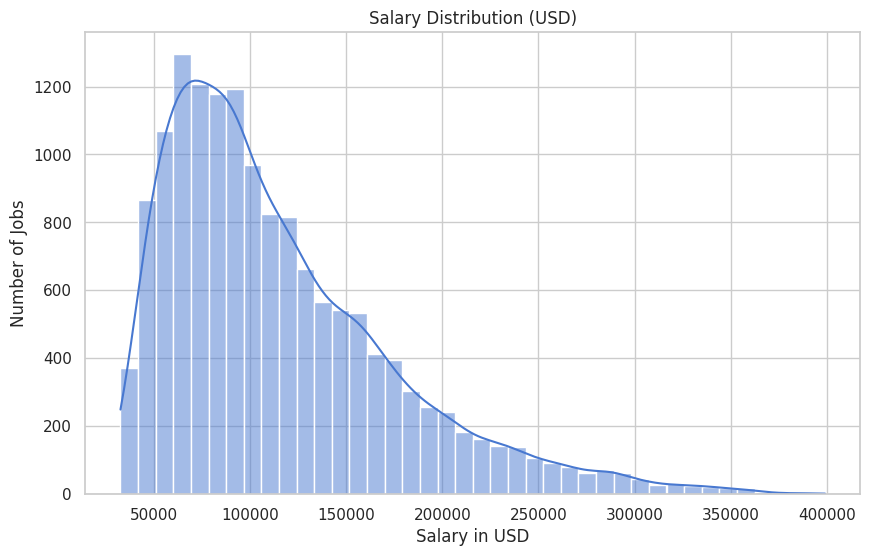

In [12]:
# Set style
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load your dataset
# df = pd.read_csv('your_dataset.csv')  # Uncomment and set your dataset path if not already loaded

# 1. Salary Distribution
sns.histplot(df['salary_usd'], bins=40, kde=True)
plt.title('Salary Distribution (USD)')
plt.xlabel('Salary in USD')
plt.ylabel('Number of Jobs')
plt.show()

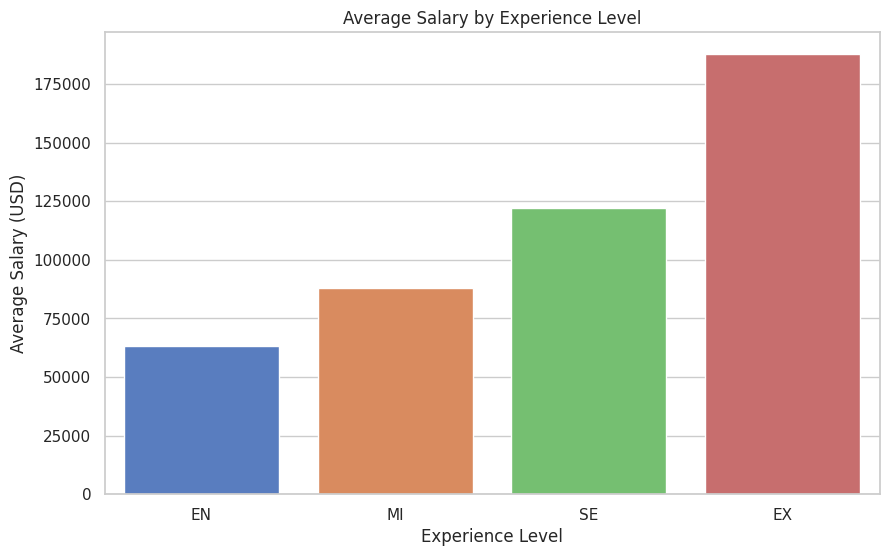

In [13]:
# 2. Average Salary by Experience Level
exp_salary = df.groupby('experience_level')['salary_usd'].mean().sort_values()
sns.barplot(x=exp_salary.index, y=exp_salary.values)
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.show()

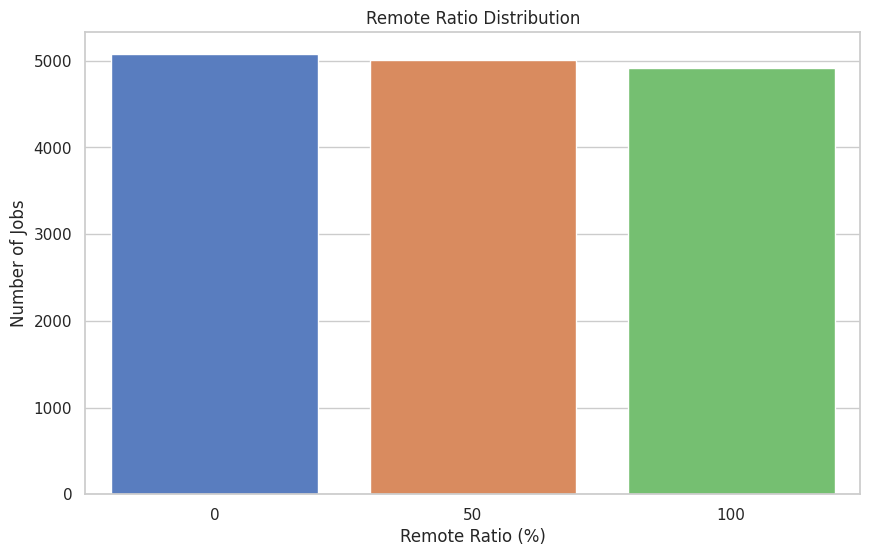

In [14]:
# 3. Remote Ratio Distribution
sns.countplot(data=df, x='remote_ratio')
plt.title('Remote Ratio Distribution')
plt.xlabel('Remote Ratio (%)')
plt.ylabel('Number of Jobs')
plt.show()

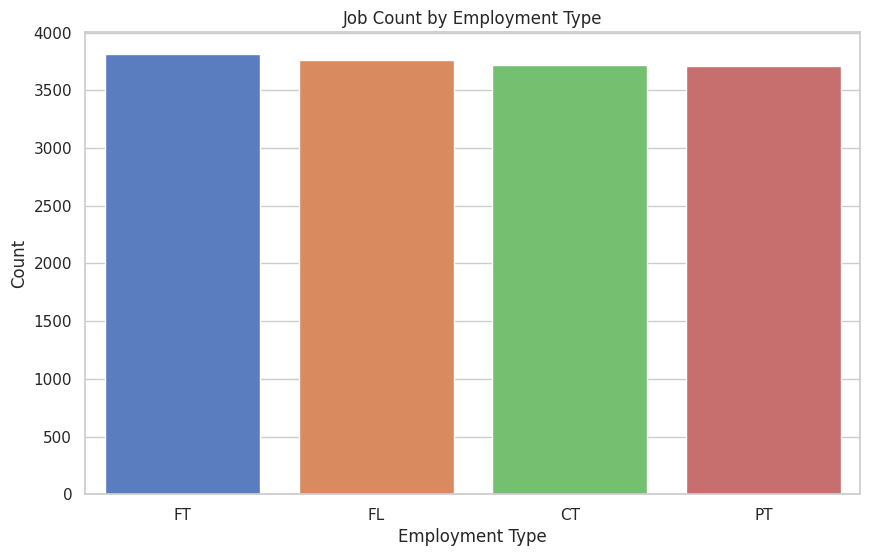

In [15]:
# 4. Job Count by Employment Type
sns.countplot(data=df, x='employment_type', order=df['employment_type'].value_counts().index)
plt.title('Job Count by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.show()


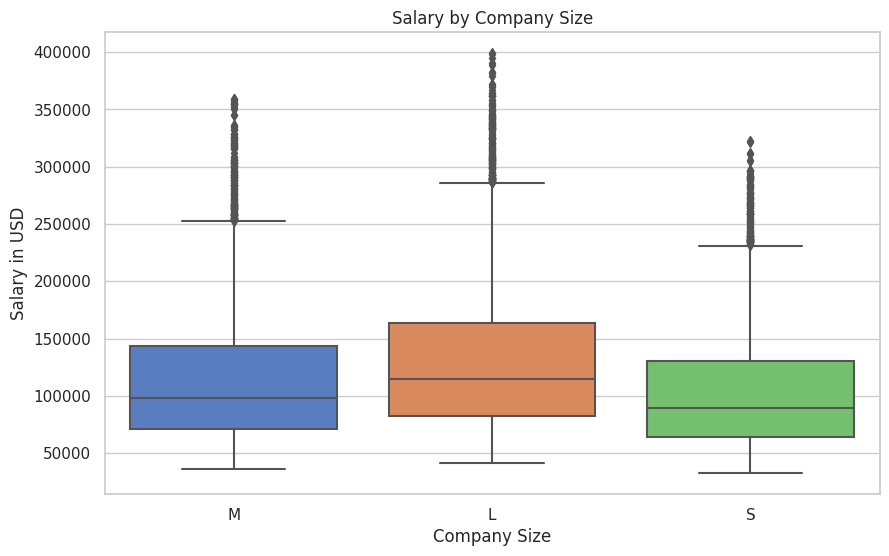

In [16]:
# 5. Salary by Company Size
sns.boxplot(data=df, x='company_size', y='salary_usd')
plt.title('Salary by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary in USD')
plt.show()

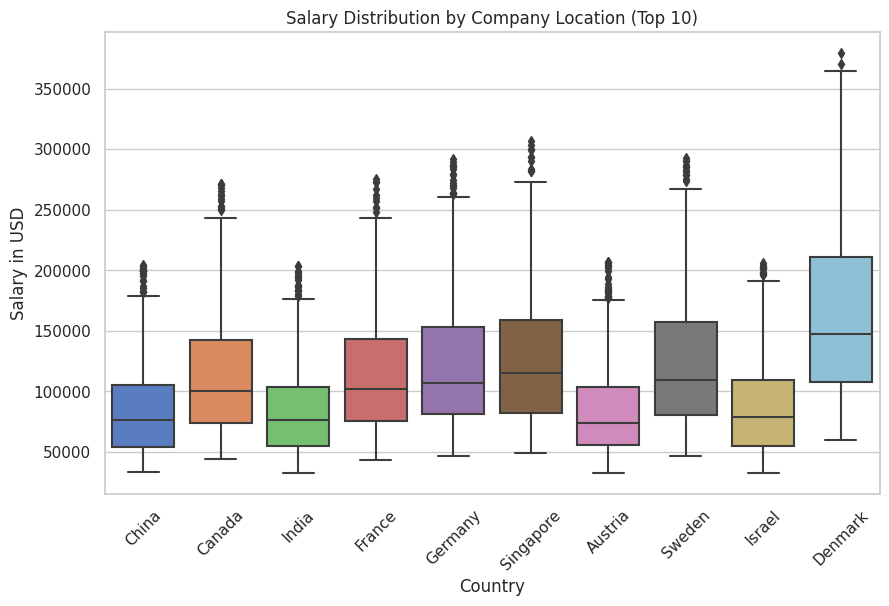

In [17]:
# 6. Salary by Country (Top 10 countries)
top_countries = df['company_location'].value_counts().nlargest(10).index
sns.boxplot(data=df[df['company_location'].isin(top_countries)],
            x='company_location', y='salary_usd')
plt.title('Salary Distribution by Company Location (Top 10)')
plt.xlabel('Country')
plt.ylabel('Salary in USD')
plt.xticks(rotation=45)
plt.show()


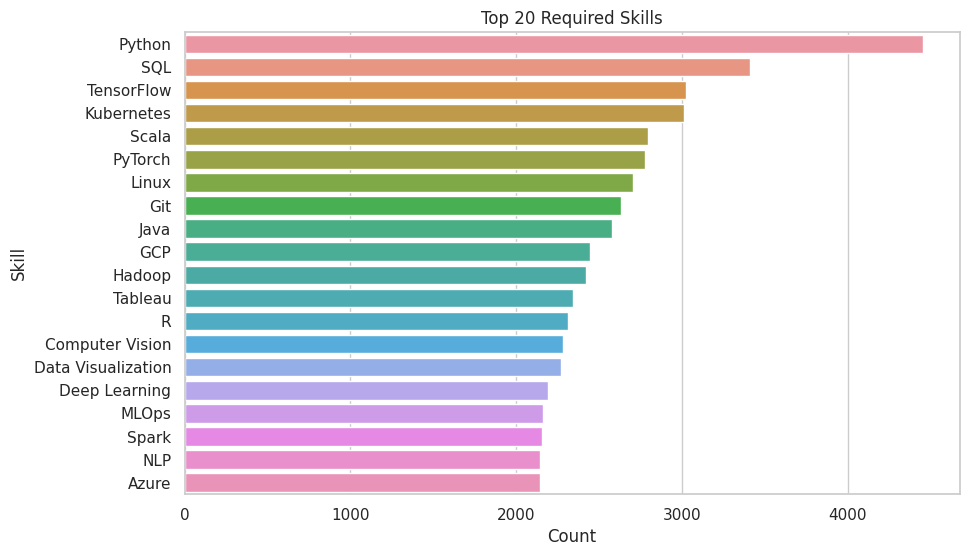

In [18]:
# 7. Popular Required Skills (Top 20)
from collections import Counter

# Flatten and count skills
skill_counter = Counter()
df['required_skills'].dropna().apply(lambda x: skill_counter.update(x.split(', ')))
common_skills = pd.DataFrame(skill_counter.most_common(20), columns=['Skill', 'Count'])

sns.barplot(data=common_skills, y='Skill', x='Count')
plt.title('Top 20 Required Skills')
plt.xlabel('Count')
plt.ylabel('Skill')
plt.show()

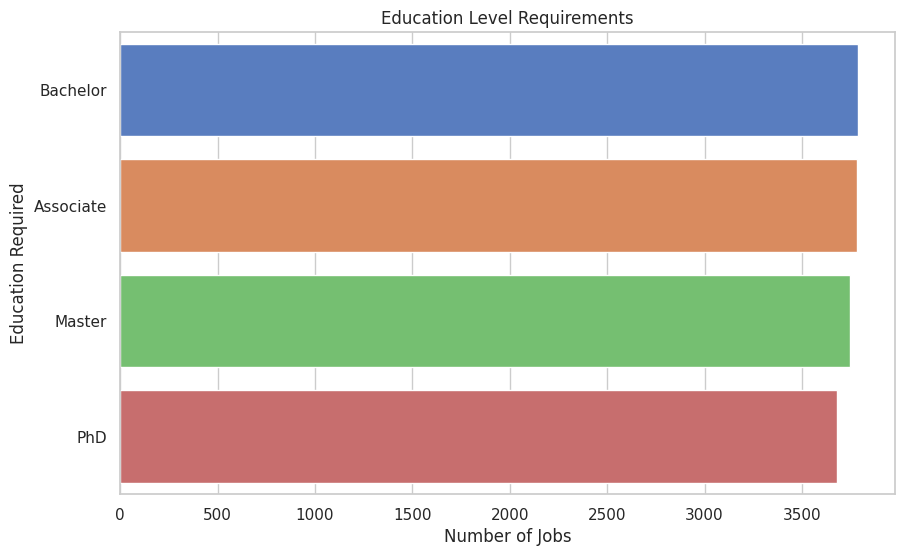

In [19]:
# 8. Education Level Requirement Count
sns.countplot(data=df, y='education_required', order=df['education_required'].value_counts().index)
plt.title('Education Level Requirements')
plt.xlabel('Number of Jobs')
plt.ylabel('Education Required')
plt.show()

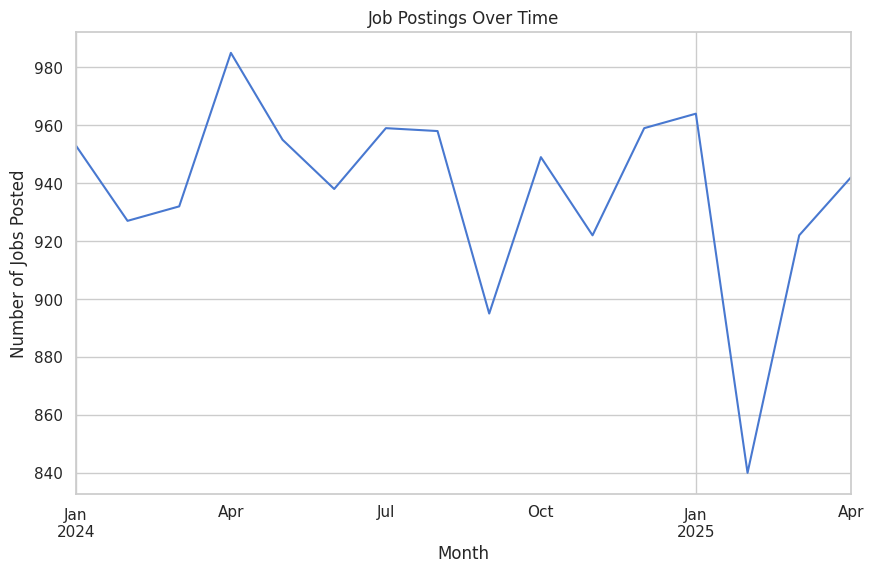

In [20]:
# 9. Job Posting Trends Over Time
df['posting_date'] = pd.to_datetime(df['posting_date'])
monthly_postings = df.resample('M', on='posting_date')['job_id'].count()

monthly_postings.plot()
plt.title('Job Postings Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Jobs Posted')
plt.grid(True)
plt.show()


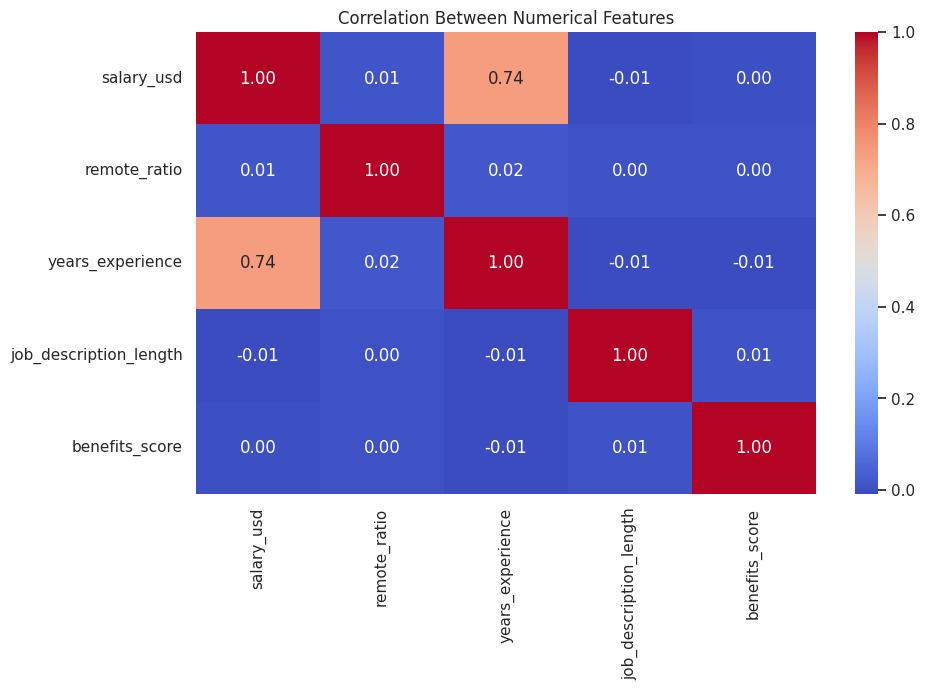

In [21]:
# 10. Correlation Heatmap
numerical_cols = ['salary_usd', 'remote_ratio', 'years_experience', 'job_description_length', 'benefits_score']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numerical Features')
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [23]:
# Drop rows with missing target or key feature columns
df = df.dropna(subset=['salary_usd', 'job_title', 'experience_level', 'employment_type'])

# Create classification target (e.g. High vs Low salary)
median_salary = df['salary_usd'].median()
df['salary_class'] = df['salary_usd'].apply(lambda x: 1 if x > median_salary else 0)  # 1: High, 0: Low

# Selecting features (dropping columns with too high cardinality or leakage)
features = [
    'job_title', 'experience_level', 'employment_type', 'company_location',
    'company_size', 'employee_residence', 'remote_ratio', 'education_required',
    'years_experience', 'industry'
]
target = 'salary_class'

df_model = df[features + [target]].copy()

In [24]:
# Label Encoding for categorical columns
label_encoders = {}
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Train-Test Split
X = df_model.drop(columns=[target])
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    results[name] = round(acc * 100, 2)

# Display accuracy results
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy (%)"]).sort_values(by="Accuracy (%)", ascending=False)
print(results_df)

                    Model  Accuracy (%)
1           Random Forest         90.83
2           Decision Tree         88.20
0     Logistic Regression         84.70
4             Naive Bayes         83.83
3  Support Vector Machine         83.67
5     K-Nearest Neighbors         82.60


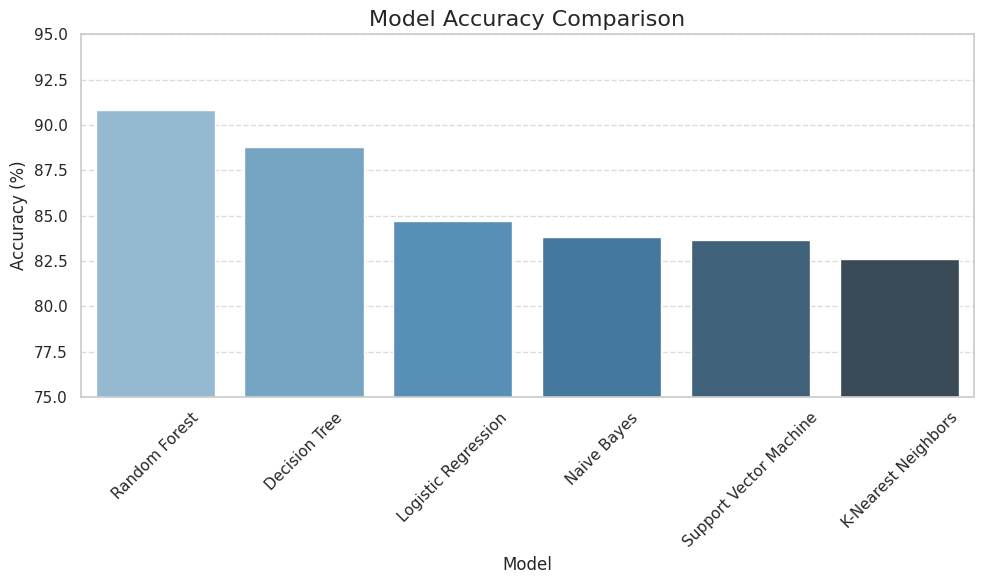

In [26]:
# Recreate the results DataFrame (if not already available)
results_df = pd.DataFrame({
    'Model': [
        'Random Forest', 'Decision Tree', 'Logistic Regression',
        'Naive Bayes', 'Support Vector Machine', 'K-Nearest Neighbors'
    ],
    'Accuracy (%)': [90.80, 88.77, 84.70, 83.83, 83.67, 82.60]
})

# Sort by accuracy
results_df = results_df.sort_values(by='Accuracy (%)', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='Accuracy (%)', palette='Blues_d')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('Accuracy (%)')
plt.ylim(75, 95)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Thank you pls upvote!!!!
